In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
import pandas as pd
import sqlite3
import os

print("All libraries loaded!")

All libraries loaded!


In [4]:
# Force Spark to use Java 21 (Java 25 can trigger UnsupportedOperationException in Hadoop UGI)
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@21/libexec/openjdk.jdk/Contents/Home"
os.environ["PATH"] = os.path.join(os.environ["JAVA_HOME"], "bin") + os.pathsep + os.environ.get("PATH", "")

spark = SparkSession.builder \
    .appName("StocksBigData") \
    .master("local[*]") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Java home:", os.environ["JAVA_HOME"])
print("Spark version:", spark.version)
print("Spark running!")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/07 19:02:37 WARN Utils: Your hostname, Atzins-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 172.24.34.72 instead (on interface en0)
26/04/07 19:02:37 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/07 19:02:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Java home: /opt/homebrew/opt/openjdk@21/libexec/openjdk.jdk/Contents/Home
Spark version: 4.1.1
Spark running!


In [5]:
# Resolve data directory whether cwd is project root or notebooks/
path_candidates = [
    os.path.abspath("data"),
    os.path.abspath("../data"),
]

RAW_PATH = next(
    (p for p in path_candidates if os.path.exists(os.path.join(p, "all_stocks_5yr.csv"))),
    None,
 )

if RAW_PATH is None:
    raise FileNotFoundError(
        "Could not find all_stocks_5yr.csv. Tried: " + ", ".join(path_candidates)
    )

# Load main dataset
df = spark.read.csv(
    os.path.join(RAW_PATH, "all_stocks_5yr.csv"),
    header=True,
    inferSchema=True,
 )

print("Schema:")
df.printSchema()
print("Total rows:", df.count())
df.show(5)

Schema:
root
 |-- date: date (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- volume: integer (nullable = true)
 |-- Name: string (nullable = true)

Total rows: 619040
+----------+-----+-----+-----+-----+--------+----+
|      date| open| high|  low|close|  volume|Name|
+----------+-----+-----+-----+-----+--------+----+
|2013-02-08|15.07|15.12|14.63|14.75| 8407500| AAL|
|2013-02-11|14.89|15.01|14.26|14.46| 8882000| AAL|
|2013-02-12|14.45|14.51| 14.1|14.27| 8126000| AAL|
|2013-02-13| 14.3|14.94|14.25|14.66|10259500| AAL|
|2013-02-14|14.94|14.96|13.16|13.99|31879900| AAL|
+----------+-----+-----+-----+-----+--------+----+
only showing top 5 rows


In [6]:
# Drop nulls
df_clean = df.dropna(subset=["close", "volume", "open"])

# Remove zero or negative values
df_clean = df_clean.filter(
    (col("close") > 0) & 
    (col("volume") > 0) & 
    (col("open") > 0)
)

# Fix date column
df_clean = df_clean.withColumn("date", to_date(col("date"), "yyyy-MM-dd"))

print("Rows after cleaning:", df_clean.count())
print("Rows removed:", df.count() - df_clean.count())
df_clean.show(5)

Rows after cleaning: 619029
Rows removed: 11
+----------+-----+-----+-----+-----+--------+----+
|      date| open| high|  low|close|  volume|Name|
+----------+-----+-----+-----+-----+--------+----+
|2013-02-08|15.07|15.12|14.63|14.75| 8407500| AAL|
|2013-02-11|14.89|15.01|14.26|14.46| 8882000| AAL|
|2013-02-12|14.45|14.51| 14.1|14.27| 8126000| AAL|
|2013-02-13| 14.3|14.94|14.25|14.66|10259500| AAL|
|2013-02-14|14.94|14.96|13.16|13.99|31879900| AAL|
+----------+-----+-----+-----+-----+--------+----+
only showing top 5 rows


In [7]:
# Add daily return column
df_transformed = df_clean.withColumn(
    "daily_return", 
    round(((col("close") - col("open")) / col("open")) * 100, 4)
)

# Add price range
df_transformed = df_transformed.withColumn(
    "price_range", 
    round(col("high") - col("low"), 4)
)

# Add year and month columns
df_transformed = df_transformed.withColumn("year", year(col("date")))
df_transformed = df_transformed.withColumn("month", month(col("date")))
df_transformed = df_transformed.withColumn("month_year", 
    concat(col("year"), lit("-"), lpad(col("month"), 2, "0")))

print("Transformations done!")
df_transformed.show(5)

Transformations done!
+----------+-----+-----+-----+-----+--------+----+------------+-----------+----+-----+----------+
|      date| open| high|  low|close|  volume|Name|daily_return|price_range|year|month|month_year|
+----------+-----+-----+-----+-----+--------+----+------------+-----------+----+-----+----------+
|2013-02-08|15.07|15.12|14.63|14.75| 8407500| AAL|     -2.1234|       0.49|2013|    2|   2013-02|
|2013-02-11|14.89|15.01|14.26|14.46| 8882000| AAL|     -2.8878|       0.75|2013|    2|   2013-02|
|2013-02-12|14.45|14.51| 14.1|14.27| 8126000| AAL|     -1.2457|       0.41|2013|    2|   2013-02|
|2013-02-13| 14.3|14.94|14.25|14.66|10259500| AAL|      2.5175|       0.69|2013|    2|   2013-02|
|2013-02-14|14.94|14.96|13.16|13.99|31879900| AAL|     -6.3588|        1.8|2013|    2|   2013-02|
+----------+-----+-----+-----+-----+--------+----+------------+-----------+----+-----+----------+
only showing top 5 rows


In [8]:
# Monthly aggregation per ticker
monthly_agg = df_transformed.groupBy("Name", "month_year").agg(
    round(avg("close"), 4).alias("avg_close"),
    round(stddev("close"), 4).alias("volatility"),
    round(avg("daily_return"), 4).alias("avg_daily_return"),
    sum("volume").alias("total_volume"),
    max("high").alias("max_price"),
    min("low").alias("min_price")
).orderBy("Name", "month_year")

print("Monthly aggregation:")
print("Rows:", monthly_agg.count())
monthly_agg.show(10)

Monthly aggregation:


Rows: 30012


+----+----------+---------+----------+----------------+------------+---------+---------+
|Name|month_year|avg_close|volatility|avg_daily_return|total_volume|max_price|min_price|
+----+----------+---------+----------+----------------+------------+---------+---------+
|   A|   2013-02|  42.8593|    1.5246|         -0.4056|    59245982|    45.35|    40.19|
|   A|   2013-03|   42.403|    0.6662|          0.0652|    66380607|    43.52|    40.73|
|   A|   2013-04|  42.0877|    1.0391|           0.045|    83068995|   44.785|    40.32|
|   A|   2013-05|  44.3795|    1.8533|          0.4055|    93213679|   47.473|   41.236|
|   A|   2013-06|  43.9065|    1.0971|         -0.3902|    68548430|    46.45|    41.85|
|   A|   2013-07|  45.3073|    1.1074|          0.1367|    52863018|     46.9|    42.72|
|   A|   2013-08|    46.69|    0.5578|          0.1736|    50122386|    48.33|    45.32|
|   A|   2013-09|   49.629|    1.7926|          0.1074|    65147629|    53.47|   46.615|
|   A|   2013-10|  51

In [9]:
# Find most volatile stocks overall
volatility_rank = df_transformed.groupBy("Name").agg(
    round(stddev("close"), 4).alias("volatility"),
    round(avg("close"), 4).alias("avg_price"),
    round(avg("daily_return"), 4).alias("avg_return")
).orderBy(desc("volatility"))

print("Top 10 most volatile stocks:")
volatility_rank.show(10)

Top 10 most volatile stocks:
+-----+----------+---------+----------+
| Name|volatility|avg_price|avg_return|
+-----+----------+---------+----------+
| PCLN|  320.5335|1312.8735|    0.0199|
| AMZN|  282.5004|   576.88|    0.0179|
|GOOGL|  187.5739| 682.2338|   -0.0173|
| GOOG|  166.4205| 725.4034|   -7.0E-4|
|  MTD|  131.3972| 356.2975|    0.0613|
|  AZO|  130.7496| 619.7037|    0.0213|
|  CMG|  130.2806|  493.256|   -8.0E-4|
| EQIX|   95.2128| 290.4309|    0.0477|
| REGN|   94.0187| 381.7184|   -0.0125|
| CHTR|    83.637| 208.0884|    0.0643|
+-----+----------+---------+----------+
only showing top 10 rows


In [10]:
OUTPUT_PATH = os.path.expanduser("../processed/")
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Save as parquet
df_transformed.write.mode("overwrite").parquet(OUTPUT_PATH + "stocks_clean.parquet")
monthly_agg.write.mode("overwrite").parquet(OUTPUT_PATH + "monthly_aggregated.parquet")

print("Saved to:", OUTPUT_PATH)
print("Files saved!")

Saved to: ../processed/
Files saved!


In [11]:
# Build SQLite path from the same project root used for RAW_PATH
project_root = os.path.dirname(RAW_PATH)
db_dir = os.path.join(project_root, "processed")
os.makedirs(db_dir, exist_ok=True)

DB_PATH = os.path.join(db_dir, "stocks_db.sqlite")
conn = sqlite3.connect(DB_PATH)

# Create tables
conn.executescript('''
CREATE TABLE IF NOT EXISTS fact_daily_prices (
    date TEXT, ticker TEXT, open REAL, high REAL,
    low REAL, close REAL, volume INTEGER,
    daily_return REAL, price_range REAL
);
CREATE TABLE IF NOT EXISTS fact_aggregated (
    ticker TEXT, month_year TEXT, avg_close REAL,
    volatility REAL, avg_daily_return REAL,
    total_volume INTEGER, max_price REAL, min_price REAL
);
''')

# Convert to pandas and save
monthly_pd = monthly_agg.toPandas()
monthly_pd.columns = ["ticker","month_year","avg_close","volatility",
                       "avg_daily_return","total_volume","max_price","min_price"]
monthly_pd.to_sql("fact_aggregated", conn, if_exists="replace", index=False)

print("DB path:", DB_PATH)
print("Rows saved to SQLite:", len(monthly_pd))
print("Tables in DB:", pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn).values)
conn.close()
# Save fact_daily_prices
prices_pd = df_transformed.select(
    col("date").cast("string").alias("date"),
    col("Name").alias("ticker"),
    "open", "high", "low", "close", "volume",
    "daily_return", "price_range"
).toPandas()
conn = sqlite3.connect(DB_PATH)
prices_pd.to_sql("fact_daily_prices", conn, if_exists="replace", index=False, chunksize=10000)
print(f"fact_daily_prices saved: {len(prices_pd):,} rows")
conn.close()


DB path: /Users/atzincruz/Documents/coding/datosmasivos/finance/processed/stocks_db.sqlite
Rows saved to SQLite: 30012
Tables in DB: [['fact_daily_prices']
 ['fact_aggregated']]


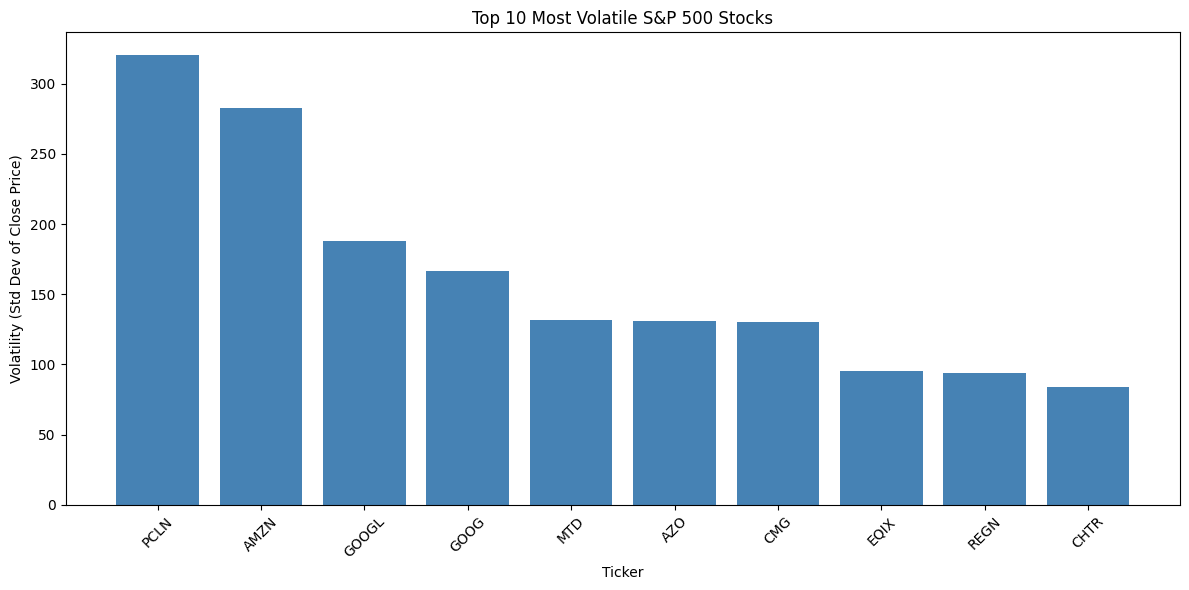

Chart saved: /Users/atzincruz/Documents/coding/datosmasivos/finance/processed/charts/volatility_chart.png


In [14]:
import matplotlib.pyplot as plt

# Top 10 most volatile stocks bar chart
vol_pd = volatility_rank.limit(10).toPandas()

plt.figure(figsize=(12,6))
plt.bar(vol_pd["Name"], vol_pd["volatility"], color="steelblue")
plt.title("Top 10 Most Volatile S&P 500 Stocks")
plt.xlabel("Ticker")
plt.ylabel("Volatility (Std Dev of Close Price)")
plt.xticks(rotation=45)
plt.tight_layout()

# Save chart inside project to avoid missing home subfolders
chart_dir = os.path.join(os.path.dirname(RAW_PATH), "processed", "charts")
os.makedirs(chart_dir, exist_ok=True)
chart_path = os.path.join(chart_dir, "volatility_chart.png")
plt.savefig(chart_path, dpi=150)
plt.show()
print("Chart saved:", chart_path)

In [15]:
import time
import os

# Create streaming folders
STREAM_INPUT = os.path.expanduser("~/Documents/coding/datosmasivos/finance/streaming/stream_input/")
STREAM_OUTPUT = os.path.expanduser("~/Documents/coding/datosmasivos/finance/streaming/stream_output/")
os.makedirs(STREAM_INPUT, exist_ok=True)
os.makedirs(STREAM_OUTPUT, exist_ok=True)

# Define schema
stream_schema = StructType([
    StructField("date", StringType(), True),
    StructField("open", DoubleType(), True),
    StructField("high", DoubleType(), True),
    StructField("low", DoubleType(), True),
    StructField("close", DoubleType(), True),
    StructField("volume", LongType(), True),
    StructField("Name", StringType(), True),
])

print("Streaming folders created!")
print("Input:", STREAM_INPUT)
print("Output:", STREAM_OUTPUT)

Streaming folders created!
Input: /Users/atzincruz/Documents/coding/datosmasivos/finance/streaming/stream_input/
Output: /Users/atzincruz/Documents/coding/datosmasivos/finance/streaming/stream_output/


In [16]:
# Split the clean data into 5 batches to simulate streaming
total_rows = df_transformed.count()
batch_size = total_rows // 5

print(f"Total rows: {total_rows}")
print(f"Batch size: {batch_size}")

for i in range(5):
    batch = df_transformed.limit(batch_size * (i + 1)) \
                          .subtract(df_transformed.limit(batch_size * i))
    
    batch_path = f"{STREAM_INPUT}batch_{i+1:03d}.csv"
    
    # Convert to pandas and save as CSV
    batch.toPandas().to_csv(batch_path, index=False)
    print(f"Batch {i+1} written → {batch_size} rows → batch_{i+1:03d}.csv")
    time.sleep(1)

print("\nAll batches written!")

Total rows: 619029
Batch size: 123805


Batch 1 written → 123805 rows → batch_001.csv


Batch 2 written → 123805 rows → batch_002.csv


Batch 3 written → 123805 rows → batch_003.csv


Batch 4 written → 123805 rows → batch_004.csv


Batch 5 written → 123805 rows → batch_005.csv

All batches written!


In [18]:
# Read stream from input folder
stream_df = spark.readStream \
    .schema(stream_schema) \
    .option("header", "true") \
    .csv(STREAM_INPUT)

# Add timestamp for windowing
stream_df = stream_df.withColumn("timestamp", current_timestamp())

# Write output in append mode (CSV compatible)
query = stream_df.writeStream \
    .outputMode("append") \
    .format("csv") \
    .option("path", STREAM_OUTPUT) \
    .option("checkpointLocation", STREAM_OUTPUT + "_checkpoint/") \
    .option("header", "true") \
    .trigger(processingTime="5 seconds") \
    .start()

print("Streaming started! Processing for 20 seconds...")
time.sleep(20)
query.stop()
print("Streaming stopped!")
print("Output files:", os.listdir(STREAM_OUTPUT))

Streaming started! Processing for 20 seconds...


Streaming stopped!
Output files: ['.part-00000-c573227c-85a0-4e9e-98bd-7699ee0b3ff9-c000.csv.crc', '.part-00006-35cf144b-734a-4710-b4a6-4cd712e31fa5-c000.csv.crc', 'part-00006-35cf144b-734a-4710-b4a6-4cd712e31fa5-c000.csv', '_checkpoint', 'part-00005-aec34da7-9674-48a1-8799-247478f64534-c000.csv', 'part-00007-0e9d4f68-ea79-4399-86f6-fb15951a3a97-c000.csv', '.part-00003-e67ab1ee-1026-4cec-91d7-2788f2472027-c000.csv.crc', '.part-00002-906ec97a-7e91-4b7a-872a-72405b638518-c000.csv.crc', '.part-00001-aa829add-1196-4f0e-ae18-da9cf6254b52-c000.csv.crc', '_spark_metadata', '.part-00005-aec34da7-9674-48a1-8799-247478f64534-c000.csv.crc', '.part-00004-afa0041e-083b-4a0c-bf1e-29386dbb8e3d-c000.csv.crc', 'part-00001-aa829add-1196-4f0e-ae18-da9cf6254b52-c000.csv', 'part-00003-e67ab1ee-1026-4cec-91d7-2788f2472027-c000.csv', 'part-00002-906ec97a-7e91-4b7a-872a-72405b638518-c000.csv', '.part-00007-0e9d4f68-ea79-4399-86f6-fb15951a3a97-c000.csv.crc', 'part-00000-c573227c-85a0-4e9e-98bd-7699ee0b3ff9-c00

In [20]:
# Read and show streaming results
stream_results = spark.read.csv(STREAM_OUTPUT, header=True, inferSchema=True)
print("Streaming output rows:", stream_results.count())
stream_results.orderBy(desc("volume")).show(10)

# Save to SQLite
conn = sqlite3.connect(DB_PATH)
stream_results.toPandas().to_sql("streaming_results", conn, 
                                  if_exists="replace", index=False)
print("Streaming results saved to SQLite!")
conn.close()

Streaming output rows: 619025


+----------+------+-----+-----+------+---------+----+--------------------+
|      date|  open| high|  low| close|   volume|Name|           timestamp|
+----------+------+-----+-----+------+---------+----+--------------------+
|2014-02-24| 47.02| 47.2|46.23| 46.23|618237630|  VZ|2026-04-07 19:40:...|
|2015-11-17| 30.57|30.75| 30.0| 30.32|431332632|  GE|2026-04-07 19:40:...|
|2016-02-11| 11.46|11.55|10.99| 11.16|375088650| BAC|2026-04-07 19:40:...|
|2013-07-25|33.545|34.88|32.75|34.359|365380568|  FB|2026-04-07 19:40:...|
|2015-04-10| 27.13|28.68| 27.0| 28.51|352701949|  GE|2026-04-07 19:40:...|
|2014-04-28| 15.33|15.41|14.86| 14.95|344935158| BAC|2026-04-07 19:40:...|
|2013-04-17| 11.91|12.02|11.45|  11.7|335205627| BAC|2026-04-07 19:40:...|
|2014-01-15| 17.23|17.42|17.11| 17.15|330005943| BAC|2026-04-07 19:40:...|
|2016-11-14| 19.41| 20.2| 19.4| 20.08|320959885| BAC|2026-04-07 19:40:...|
|2016-11-09| 17.66|18.05| 17.4| 17.97|319516881| BAC|2026-04-07 19:40:...|
+----------+------+-----+

In [22]:
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

# Pick 5 tickers to forecast
tickers = ["AAPL", "MSFT", "GOOGL", "BAC", "GE"]

# Load clean data as pandas
stocks_pd = df_transformed.toPandas()

all_forecasts = []

for ticker in tickers:
    print(f"Forecasting {ticker}...")
    
    # Filter ticker
    df_ticker = stocks_pd[stocks_pd["Name"] == ticker][["date", "close"]].copy()
    df_ticker.columns = ["ds", "y"]
    df_ticker["ds"] = pd.to_datetime(df_ticker["ds"])
    df_ticker = df_ticker.dropna().sort_values("ds")
    
    # Train model
    model = Prophet(daily_seasonality=False, 
                   weekly_seasonality=True,
                   yearly_seasonality=True)
    model.fit(df_ticker)
    
    # Forecast 30 days ahead
    future = model.make_future_dataframe(periods=30)
    forecast = model.predict(future)
    
    # Keep relevant columns
    forecast["ticker"] = ticker
    forecast["actual_close"] = None
    
    # Match actuals where available
    merged = forecast[["ds","yhat","yhat_lower","yhat_upper","ticker"]].copy()
    merged.columns = ["date","predicted_close","lower_bound","upper_bound","ticker"]
    all_forecasts.append(merged)
    
    print(f"  {ticker} done — last predicted close: {merged['predicted_close'].iloc[-1]:.2f}")

# Combine all forecasts
forecasts_df = pd.concat(all_forecasts)
print(f"\nTotal forecast rows: {len(forecasts_df)}")
forecasts_df.head()

Importing plotly failed. Interactive plots will not work.
19:43:03 - cmdstanpy - INFO - Chain [1] start processing                        


Forecasting AAPL...


19:43:04 - cmdstanpy - INFO - Chain [1] done processing
19:43:04 - cmdstanpy - INFO - Chain [1] start processing


  AAPL done — last predicted close: 183.47
Forecasting MSFT...


19:43:05 - cmdstanpy - INFO - Chain [1] done processing
19:43:05 - cmdstanpy - INFO - Chain [1] start processing


...

19:43:06 - cmdstanpy - INFO - Chain [1] done processing
19:43:06 - cmdstanpy - INFO - Chain [1] start processing


  BAC done — last predicted close: 31.31
Forecasting GE...


19:43:06 - cmdstanpy - INFO - Chain [1] done processing


  GE done — last predicted close: 15.61

Total forecast rows: 6445


,date,predicted_close,lower_bound,upper_bound,ticker
0,2013-02-08,58.114846,53.207873,63.389234,AAPL
1,2013-02-11,59.575303,54.063931,64.990893,AAPL
2,2013-02-12,60.017656,54.923449,65.479178,AAPL
3,2013-02-13,60.348858,55.306695,65.810437,AAPL
4,2013-02-14,60.686399,55.283382,65.979811,AAPL


In [23]:
conn = sqlite3.connect(DB_PATH)
forecasts_df.to_sql("ml_predictions", conn, if_exists="replace", index=False)

# Verify
result = pd.read_sql("SELECT ticker, COUNT(*) as rows, ROUND(AVG(predicted_close),2) as avg_predicted FROM ml_predictions GROUP BY ticker", conn)
print("ML Predictions saved to SQLite:")
print(result)
conn.close()

ML Predictions saved to SQLite:
  ticker  rows  avg_predicted
0   AAPL  1289         110.77
1    BAC  1289          18.01
2     GE  1289          26.27
3  GOOGL  1289         692.57
4   MSFT  1289          51.97


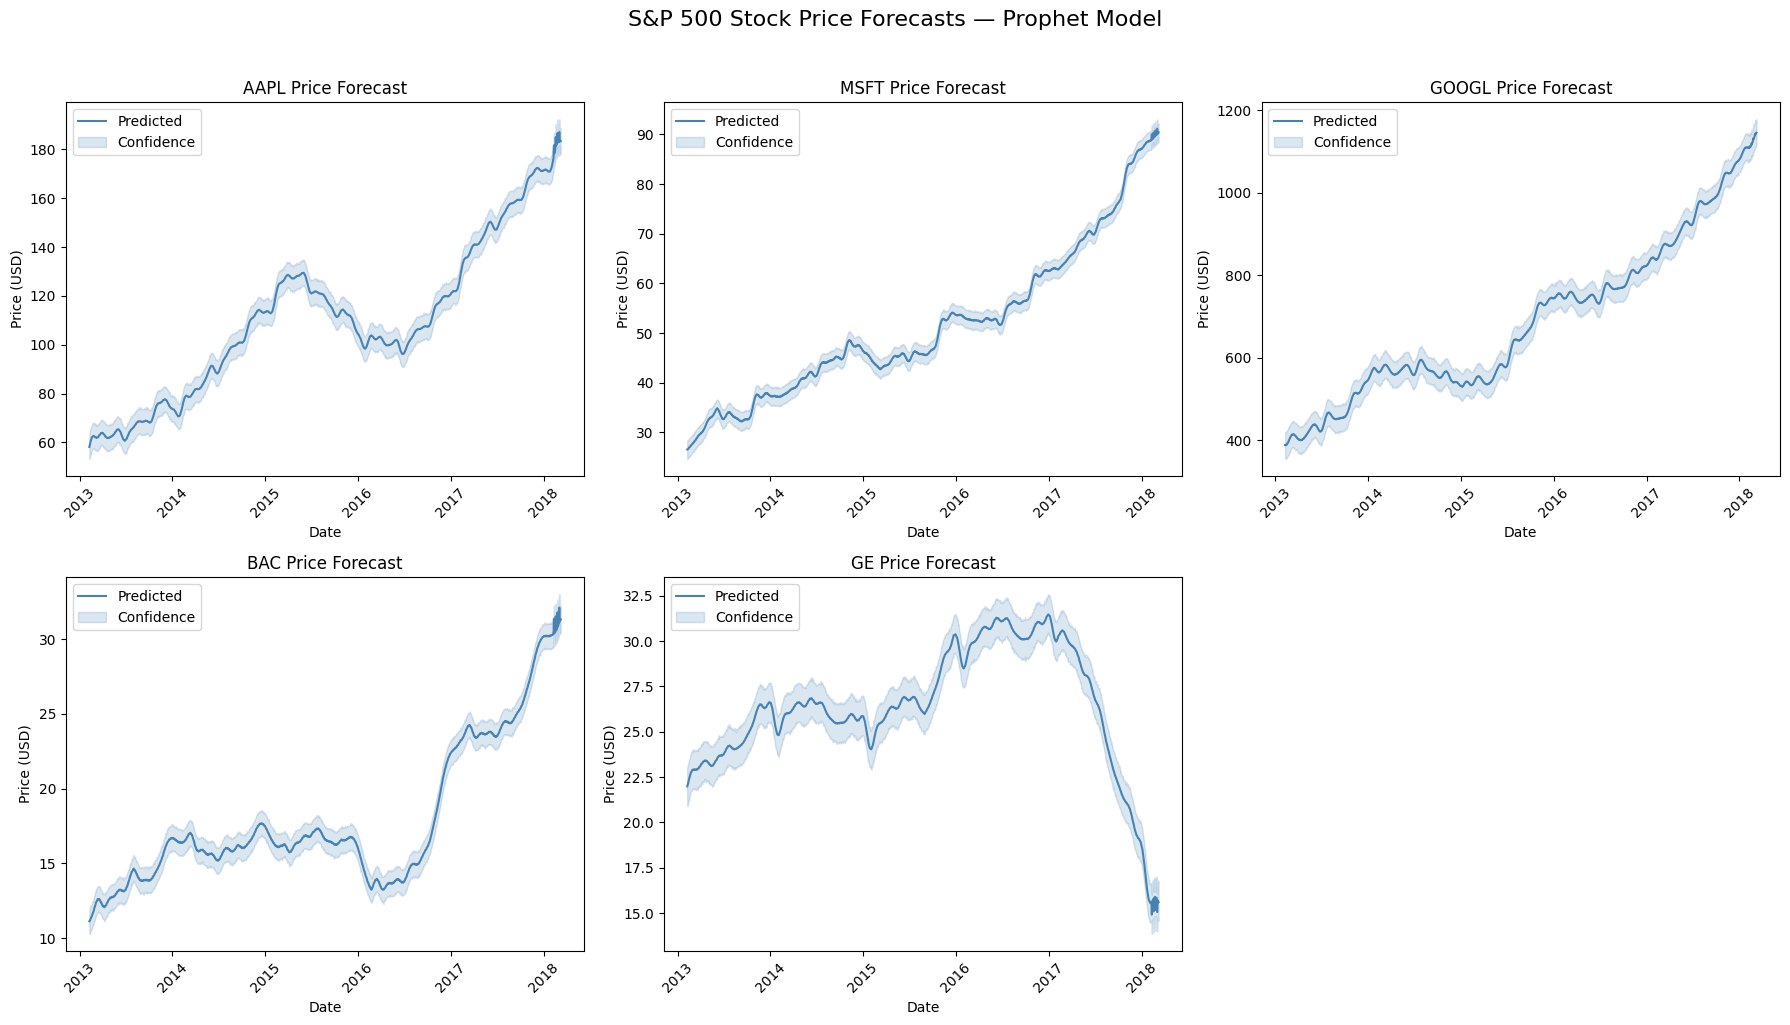

Forecast chart saved!


In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    df_plot = forecasts_df[forecasts_df["ticker"] == ticker]
    
    axes[i].plot(pd.to_datetime(df_plot["date"]), df_plot["predicted_close"], 
                 color="steelblue", linewidth=1.5, label="Predicted")
    axes[i].fill_between(pd.to_datetime(df_plot["date"]), 
                          df_plot["lower_bound"], df_plot["upper_bound"],
                          alpha=0.2, color="steelblue", label="Confidence")
    axes[i].set_title(f"{ticker} Price Forecast")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Price (USD)")
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

# Hide the 6th empty subplot
axes[5].set_visible(False)

plt.suptitle("S&P 500 Stock Price Forecasts — Prophet Model", fontsize=16, y=1.02)
plt.tight_layout()

CHARTS_PATH = os.path.expanduser("~/Documents/coding/datosmasivos/finance/processed/charts/")
os.makedirs(CHARTS_PATH, exist_ok=True)
plt.savefig(CHARTS_PATH + "forecast_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Forecast chart saved!")

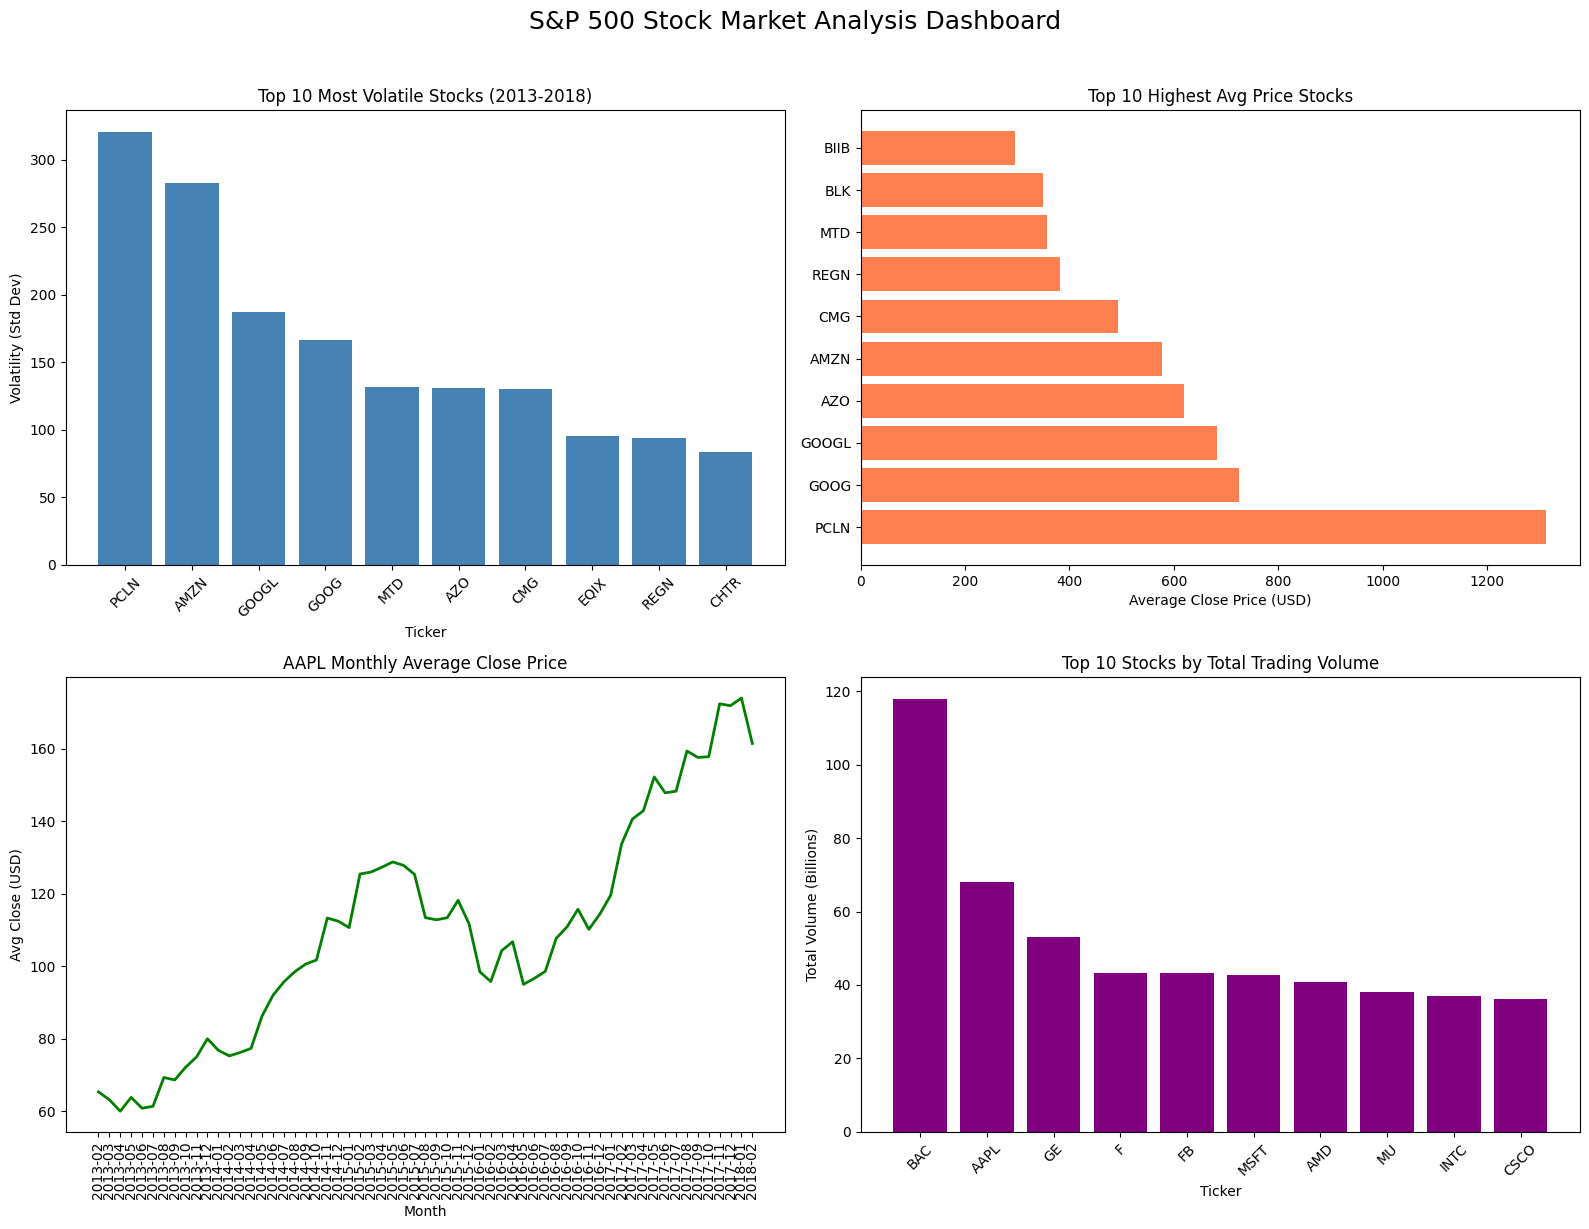

Dashboard saved!


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1 — Top 10 most volatile stocks
vol_pd = volatility_rank.limit(10).toPandas()
axes[0,0].bar(vol_pd["Name"], vol_pd["volatility"], color="steelblue")
axes[0,0].set_title("Top 10 Most Volatile Stocks (2013-2018)")
axes[0,0].set_xlabel("Ticker")
axes[0,0].set_ylabel("Volatility (Std Dev)")
axes[0,0].tick_params(axis='x', rotation=45)

# Chart 2 — Average close price by ticker (top 10)
avg_pd = volatility_rank.orderBy(desc("avg_price")).limit(10).toPandas()
axes[0,1].barh(avg_pd["Name"], avg_pd["avg_price"], color="coral")
axes[0,1].set_title("Top 10 Highest Avg Price Stocks")
axes[0,1].set_xlabel("Average Close Price (USD)")

# Chart 3 — Monthly avg close for AAPL
aapl_monthly = monthly_agg.filter(col("Name") == "AAPL").orderBy("month_year").toPandas()
axes[1,0].plot(aapl_monthly["month_year"], aapl_monthly["avg_close"], 
               color="green", linewidth=2)
axes[1,0].set_title("AAPL Monthly Average Close Price")
axes[1,0].set_xlabel("Month")
axes[1,0].set_ylabel("Avg Close (USD)")
axes[1,0].tick_params(axis='x', rotation=90)

# Chart 4 — Volume comparison top 5 tickers
vol_comp = df_transformed.groupBy("Name").agg(
    sum("volume").alias("total_volume")
).orderBy(desc("total_volume")).limit(10).toPandas()
axes[1,1].bar(vol_comp["Name"], vol_comp["total_volume"] / 1e9, color="purple")
axes[1,1].set_title("Top 10 Stocks by Total Trading Volume")
axes[1,1].set_xlabel("Ticker")
axes[1,1].set_ylabel("Total Volume (Billions)")
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle("S&P 500 Stock Market Analysis Dashboard", fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig(CHARTS_PATH + "dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved!")

In [28]:
import os
import pandas as pd

# Fixed path - there's a nested folder
individual_path = os.path.expanduser("~/Documents/coding/datosmasivos/finance/data/individual_stocks_5yr/individual_stocks_5yr/")
files = [f for f in os.listdir(individual_path) if f.endswith('.csv')]
total_rows = 0
for f in files:
    df_temp = pd.read_csv(individual_path + f)
    total_rows += len(df_temp)

print(f"Total files: {len(files)}")
print(f"Total rows across all individual files: {total_rows:,}")
print(f"Combined with all_stocks_5yr.csv: {total_rows + 619040:,}")

Total files: 505
Total rows across all individual files: 619,040
Combined with all_stocks_5yr.csv: 1,238,080


In [29]:
# Explicit JOIN — sector enrichment
company_data = [
    ("AAPL", "Technology"), ("MSFT", "Technology"),
    ("GOOGL", "Technology"), ("AMZN", "Consumer Discretionary"),
    ("BAC", "Financials"), ("JPM", "Financials"),
    ("GE", "Industrials"), ("F", "Consumer Discretionary"),
    ("JNJ", "Healthcare"), ("XOM", "Energy"),
    ("PG", "Consumer Staples"), ("KO", "Consumer Staples"),
    ("WMT", "Consumer Staples"), ("DIS", "Communication"),
    ("VZ", "Communication"), ("T", "Communication"),
]
company_df = spark.createDataFrame(company_data, ["Name", "Sector"])

# JOIN clean stock data with sector metadata
df_with_sector = df_transformed.join(company_df, on="Name", how="left")

# Aggregate by sector
sector_analysis = df_with_sector.groupBy("Sector").agg(
    round(avg("daily_return"), 4).alias("avg_daily_return"),
    round(avg("price_range"), 4).alias("avg_price_range"),
    round(stddev("close"), 4).alias("avg_volatility"),
    sum("volume").alias("total_volume")
).orderBy(desc("total_volume"))

print("Sector analysis via JOIN:")
sector_analysis.show()

# Filter out NULL sector (tickers not in mapping) then save
sector_clean = sector_analysis.filter(col("Sector").isNotNull())
print(f"Sectors after filtering NULL: {sector_clean.count()}")
sector_clean.show()
conn = sqlite3.connect(DB_PATH)
sector_clean.toPandas().to_sql("sector_analysis", conn, if_exists="replace", index=False)
print("Sector join saved to SQLite!")
conn.close()

Sector analysis via JOIN:


+--------------------+----------------+---------------+--------------+-------------+
|              Sector|avg_daily_return|avg_price_range|avg_volatility| total_volume|
+--------------------+----------------+---------------+--------------+-------------+
|                NULL|           0.036|          1.503|       90.8045|2195904064937|
|          Financials|          0.0131|         0.6868|       27.5399| 138770546448|
|          Technology|          0.0281|         4.4287|      305.3981| 113781953746|
|       Communication|           0.007|         0.8216|       26.2177|  61739933104|
|         Industrials|         -0.0195|         0.3778|        3.3176|  53023644686|
|Consumer Discreti...|         -0.0221|         5.5793|      345.1092|  48084786014|
|    Consumer Staples|          0.0339|          0.798|       18.6964|  38884114046|
|              Energy|          0.0223|         1.1854|        6.9595|  15610614698|
|          Healthcare|          0.0315|         1.2568|       16.

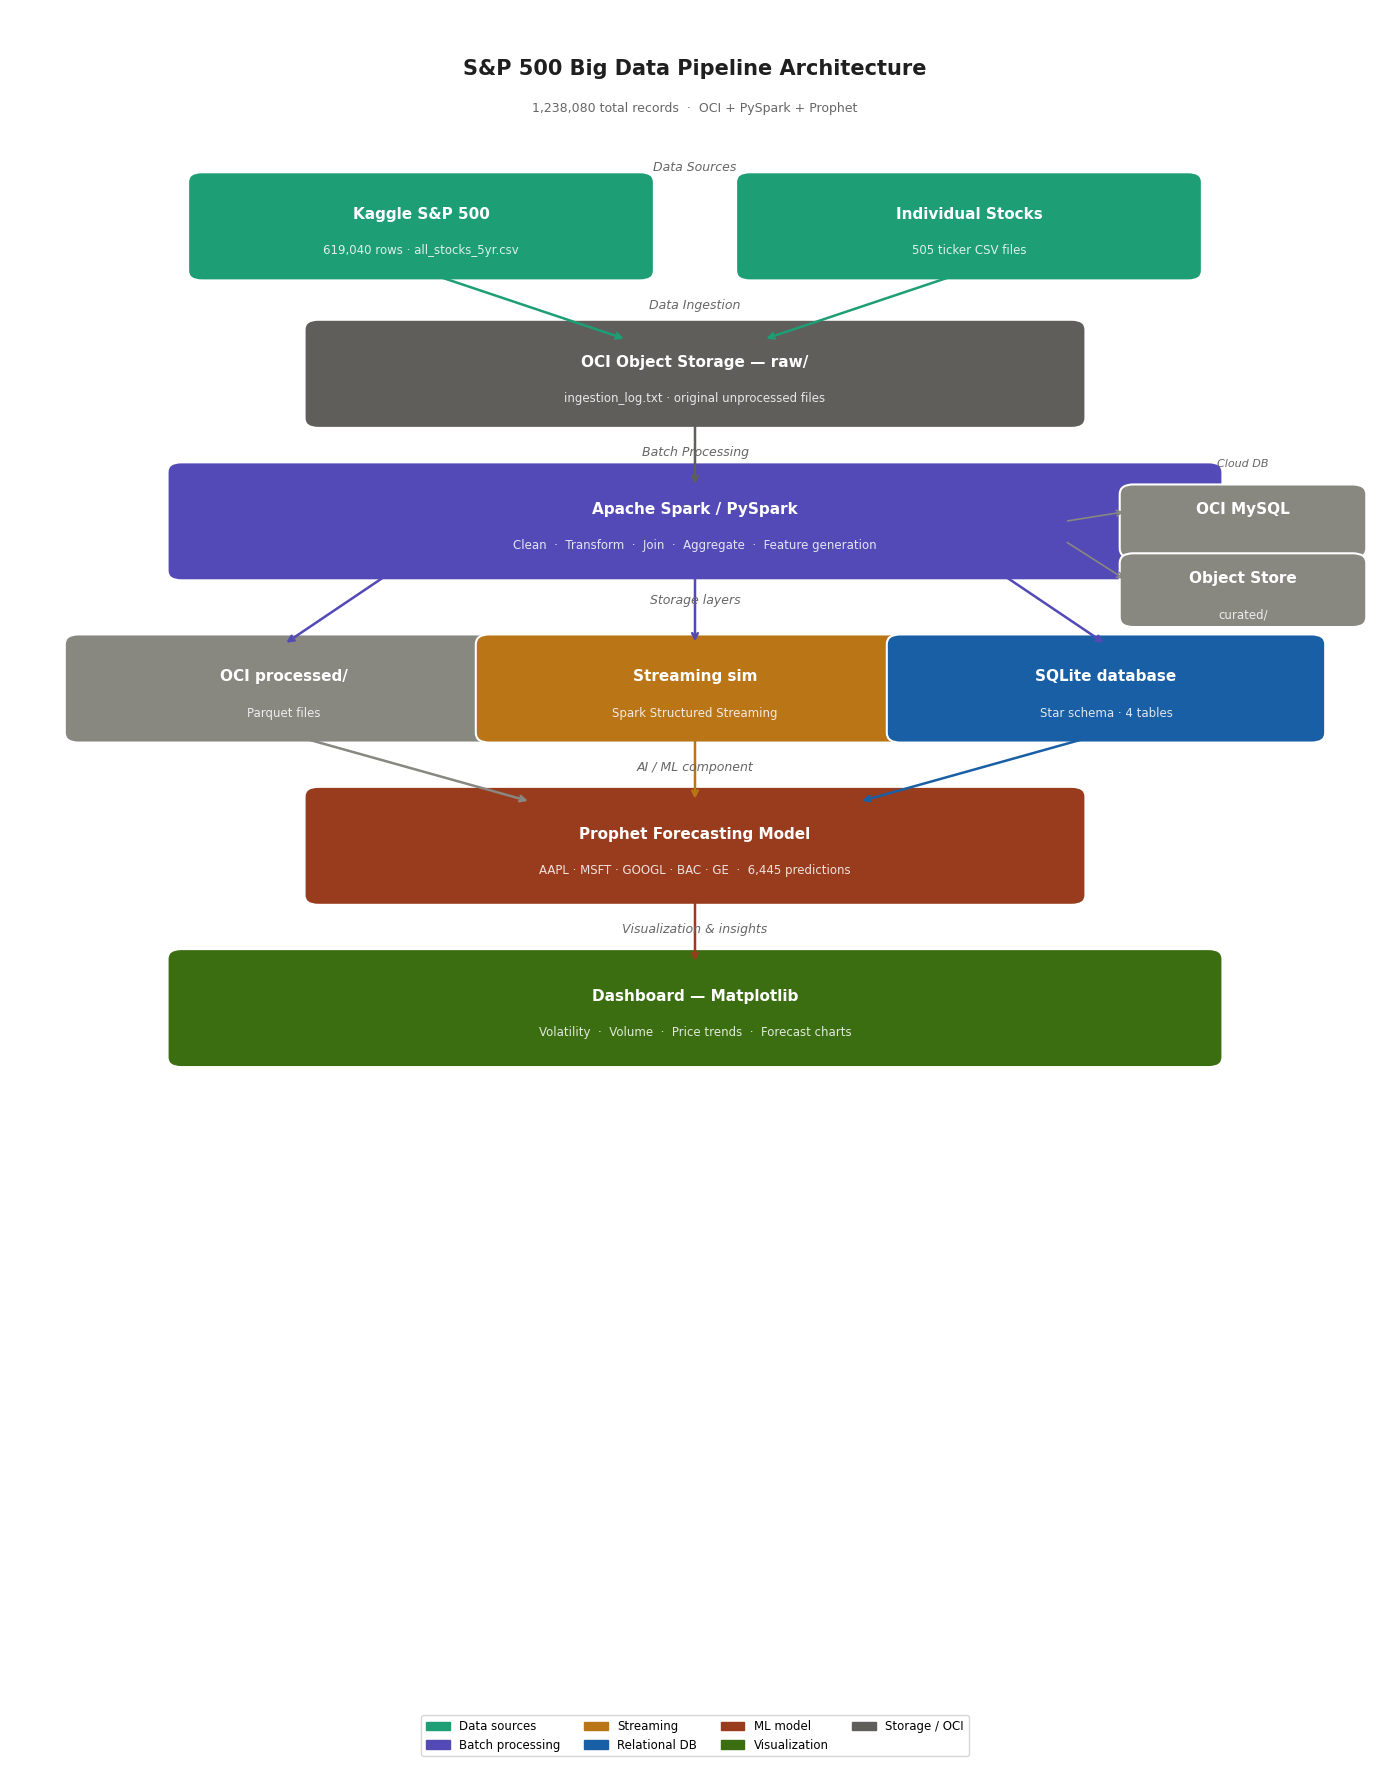

Pipeline diagram saved!


In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(1, 1, figsize=(14, 18))
ax.set_xlim(0, 10)
ax.set_ylim(0, 18)
ax.axis('off')
fig.patch.set_facecolor('#FFFFFF')

def box(ax, x, y, w, h, label, sublabel, color, textcolor='white'):
    rect = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle="round,pad=0.1", 
                          facecolor=color, edgecolor='white', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x, y + 0.12, label, ha='center', va='center',
            fontsize=11, fontweight='bold', color=textcolor)
    if sublabel:
        ax.text(x, y - 0.25, sublabel, ha='center', va='center',
                fontsize=8.5, color=textcolor, alpha=0.85)

def arrow(ax, x1, y1, x2, y2, color='#888888'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color,
                               lw=1.8, connectionstyle='arc3,rad=0.0'))

def section_label(ax, x, y, text):
    ax.text(x, y, text, ha='center', va='center',
            fontsize=9, color='#666666', style='italic')

TEAL    = '#1D9E75'
PURPLE  = '#534AB7'
AMBER   = '#BA7517'
BLUE    = '#185FA5'
CORAL   = '#993C1D'
GREEN   = '#3B6D11'
GRAY    = '#5F5E5A'
LGRAY   = '#888780'

# ── Title ──────────────────────────────────────────────
ax.text(5, 17.4, 'S&P 500 Big Data Pipeline Architecture',
        ha='center', va='center', fontsize=15, fontweight='bold', color='#1F1F1F')
ax.text(5, 17.0, '1,238,080 total records  ·  OCI + PySpark + Prophet',
        ha='center', va='center', fontsize=9, color='#666666')

# ── Layer 1: Data Sources ───────────────────────────────
section_label(ax, 5, 16.4, 'Data Sources')
box(ax, 3.0, 15.8, 3.2, 0.9, 'Kaggle S&P 500',      '619,040 rows · all_stocks_5yr.csv', TEAL)
box(ax, 7.0, 15.8, 3.2, 0.9, 'Individual Stocks',    '505 ticker CSV files', TEAL)

# ── Layer 2: Ingestion ─────────────────────────────────
arrow(ax, 3.0, 15.35, 4.5, 14.65, TEAL)
arrow(ax, 7.0, 15.35, 5.5, 14.65, TEAL)
section_label(ax, 5, 15.0, 'Data Ingestion')
box(ax, 5.0, 14.3, 5.5, 0.9, 'OCI Object Storage — raw/',
    'ingestion_log.txt · original unprocessed files', GRAY)

# ── Layer 3: Batch Processing ──────────────────────────
arrow(ax, 5.0, 13.85, 5.0, 13.15, GRAY)
section_label(ax, 5, 13.5, 'Batch Processing')
box(ax, 5.0, 12.8, 7.5, 1.0, 'Apache Spark / PySpark',
    'Clean  ·  Transform  ·  Join  ·  Aggregate  ·  Feature generation', PURPLE)

# ── Layer 4: Processing outputs ───────────────────────
arrow(ax, 2.8, 12.3, 2.0, 11.55, PURPLE)
arrow(ax, 5.0, 12.3, 5.0, 11.55, PURPLE)
arrow(ax, 7.2, 12.3, 8.0, 11.55, PURPLE)
section_label(ax, 5, 12.0, 'Storage layers')
box(ax, 2.0, 11.1, 3.0, 0.9, 'OCI processed/',    'Parquet files', LGRAY)
box(ax, 5.0, 11.1, 3.0, 0.9, 'Streaming sim',     'Spark Structured Streaming', AMBER)
box(ax, 8.0, 11.1, 3.0, 0.9, 'SQLite database',   'Star schema · 4 tables', BLUE)

# ── Layer 5: ML Model ─────────────────────────────────
arrow(ax, 2.0, 10.65, 3.8, 9.95, LGRAY)
arrow(ax, 5.0, 10.65, 5.0, 9.95, AMBER)
arrow(ax, 8.0, 10.65, 6.2, 9.95, BLUE)
section_label(ax, 5, 10.3, 'AI / ML component')
box(ax, 5.0, 9.5, 5.5, 1.0, 'Prophet Forecasting Model',
    'AAPL · MSFT · GOOGL · BAC · GE  ·  6,445 predictions', CORAL)

# ── Layer 6: Visualization ────────────────────────────
arrow(ax, 5.0, 9.0, 5.0, 8.3, CORAL)
section_label(ax, 5, 8.65, 'Visualization & insights')
box(ax, 5.0, 7.85, 7.5, 1.0, 'Dashboard — Matplotlib',
    'Volatility  ·  Volume  ·  Price trends  ·  Forecast charts', GREEN)

# ── OCI Side storage ──────────────────────────────────
box(ax, 9.0, 12.8, 1.6, 0.55, 'OCI MySQL', '', LGRAY, 'white')
box(ax, 9.0, 12.1, 1.6, 0.55, 'Object Store', 'curated/', LGRAY, 'white')
ax.annotate('', xy=(8.15, 12.9), xytext=(7.7, 12.8),
            arrowprops=dict(arrowstyle='->', color=LGRAY, lw=1.2))
ax.annotate('', xy=(8.15, 12.2), xytext=(7.7, 12.6),
            arrowprops=dict(arrowstyle='->', color=LGRAY, lw=1.2))
ax.text(9.0, 13.35, 'Cloud DB', ha='center', fontsize=8, color='#666666', style='italic')

# ── Legend ────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color=TEAL,   label='Data sources'),
    mpatches.Patch(color=PURPLE, label='Batch processing'),
    mpatches.Patch(color=AMBER,  label='Streaming'),
    mpatches.Patch(color=BLUE,   label='Relational DB'),
    mpatches.Patch(color=CORAL,  label='ML model'),
    mpatches.Patch(color=GREEN,  label='Visualization'),
    mpatches.Patch(color=GRAY,   label='Storage / OCI'),
]
ax.legend(handles=legend_items, loc='lower center', ncol=4,
          fontsize=8.5, frameon=True, fancybox=True,
          bbox_to_anchor=(0.5, 0.01))

plt.tight_layout()

import os
CHARTS_PATH = os.path.expanduser("~/Documents/coding/datosmasivos/finance/processed/charts/")
os.makedirs(CHARTS_PATH, exist_ok=True)
plt.savefig(CHARTS_PATH + "pipeline_architecture.png", dpi=150, bbox_inches="tight")
plt.show()
print("Pipeline diagram saved!")